# Implementação do algoritmo de Trust-Region 

O presente notebook tem como objetivo implementar o algoritmo de Trust-Region apresentado no livro Numerical Optmization em Python, a fim de servir como recurso didático para a melhor compreensão do método de otimização.

**Autor:** Edélio Gabriel M. de Jesus

## Importação das bibliotecas necessárias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

## Construção da função de otimização por Trust-Region

O código abaixo implementa uma otimização da função de **Rosenbrock** usando o método de **Trust Region com Cauchy Point** e visualiza a trajetória da iteração. Vamos detalhar cada componente matemático.

---

### 1. Função de Rosenbrock

A função de Rosenbrock é definida como:

$$
f(x, y) = (1 - x)^2 + 100 (y - x^2)^2
$$

- É uma função **não convexa** com um **mínimo global** em \( (x, y) = (1,1) \), onde \( f(1,1) = 0 \).
- É comumente usada para testar algoritmos de otimização devido ao seu **vale alongado e estreito**, que torna difícil a convergência para métodos de gradiente simples.

---

### 2. Gradiente

O gradiente da função é o vetor das derivadas parciais:

$$
\nabla f(x, y) =
\begin{bmatrix}
\frac{\partial f}{\partial x} \\
\frac{\partial f}{\partial y}
\end{bmatrix}
=
\begin{bmatrix}
-2(1 - x) - 400 x (y - x^2) \\
200 (y - x^2)
\end{bmatrix}
$$

- O gradiente indica a **direção de subida mais rápida** da função.
- No algoritmo de otimização, usamos o gradiente para determinar a direção em que devemos **atualizar os parâmetros**.

---

### 3. Hessiana

A Hessiana é a matriz das derivadas segundas:

$$
H(x, y) =
\begin{bmatrix}
\frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\
\frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2}
\end{bmatrix}
=
\begin{bmatrix}
2 - 400 (y - 3x^2) & -400 x \\
-400 x & 200
\end{bmatrix}
$$

- A Hessiana descreve a **curvatura local** da função.
- É usada no método de Trust Region para ajustar o **tamanho do passo** de forma mais segura.

---

### 4. Trust Region com Cauchy Point

O método de **Trust Region** busca minimizar a função dentro de uma "região de confiança" ao redor do ponto atual \(x_k\):

$$
\min_s \quad m_k(s) = f(x_k) + \nabla f(x_k)^T s + \frac{1}{2} s^T H(x_k) s
\quad \text{sujeito a } \|s\| \le \Delta
$$

- $\Delta$ é o **raio da região de confiança**.
- O **Cauchy Point** é uma aproximação da solução do subproblema de Trust Region ao longo da **direção do gradiente negativo**.
- Isso garante que cada passo **reduza a função de forma segura** sem depender da inversa da Hessiana completa.

---

### 5. Visualização

O código plota:

1. **Curvas de nível** da função de Rosenbrock ($f(x,y) = \text{constante}$) usando `plt.contour`.
2. **Trajetória do algoritmo** com pontos vermelhos conectados (`'ro-'`), mostrando como o método converge para o mínimo.

O resultado permite observar **como o Trust Region evita passos excessivos** em regiões de alta curvatura e segue o vale estreito da função até $(1,1)$.

In [2]:
def trust_region_cauchy(f, grad, hess, x0,
                        Delta0=1.0,
                        Delta_max=10.0,
                        eta=0.1,
                        tol=1e-8,
                        max_iter=10000):
    x = x0.copy()
    Delta = Delta0

    history = [x0.copy()]

    for k in range(max_iter):

        # Gradiante e Hessiana
        g = grad(x)
        B = hess(x)

        # Critério de parada
        if np.linalg.norm(g) < tol:
            print(f'Convergiu em {k} iterações.')
            break

        # Cauchy Point
        g_norm = np.linalg.norm(g)
        gBg = g.T @ B @ g

        # Caso de curvatura negativa ou zero
        if gBg <= 0:
            alpha = Delta / g_norm
        else:
            alpha_star = (g @ g) / gBg
            alpha = min(alpha_star, Delta / g_norm)

        p = - alpha * g

        # Reduções
        f_x = f(x)
        f_new = f(x + p)

        ## Redução real
        actual_reduction = f_x - f_new

        ## Redução prevista
        prev_reduction = - (g @ p + 0.5 * p @ B @ p)

        # Evitar divisão por 0 
        if prev_reduction == 0:
            rho = 0
        else:
            rho = actual_reduction / prev_reduction

        if rho < 0.25:
            Delta *= 0.25
        elif rho > 0.75 and np.linalg.norm(p) >= Delta:
            Delta = min(2 * Delta, Delta_max)

        # Aceitar ou Negar passo 
        if rho > eta:
            x = x + p 

        history.append(x.copy())

    return x, history

## Visualizando a otimização

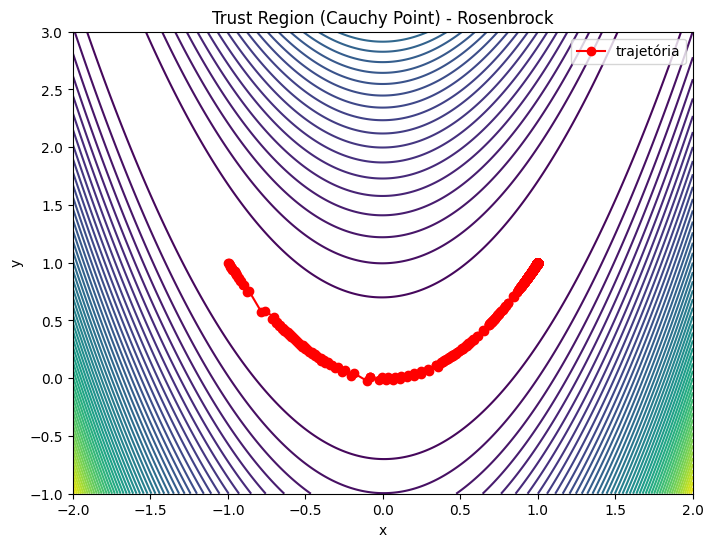

In [3]:
import matplotlib.pyplot as plt

# Função Rosenbrock
def f(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def grad(x):
    dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
    dfdy = 200*(x[1] - x[0]**2)
    return np.array([dfdx, dfdy])

def hess(x):
    d2fdx2 = 2 - 400*(x[1] - 3*x[0]**2)
    d2fdxdy = -400*x[0]
    d2fdy2 = 200
    return np.array([[d2fdx2, d2fdxdy],
                     [d2fdxdy, d2fdy2]])

# Rodar algoritmo
# =========================
x0 = np.array([-1, 1])
x_opt, history = trust_region_cauchy(f, grad, hess, x0)

# =========================
# Plot
# =========================
history = np.array(history)
xs = history[:, 0]
ys = history[:, 1]

x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = (1 - X)**2 + 100*(Y - X**2)**2

plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=50)
plt.plot(xs, ys, 'ro-', label='trajetória')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trust Region (Cauchy Point) - Rosenbrock')
plt.legend()
plt.show()